<a href="https://colab.research.google.com/github/saumya112-IN/BioBridge-Foundational-Model/blob/main/BioBridge_Multimodal_BioAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Install Dependencies

In this section, we install all required libraries for:

- Deep Learning
- Dataset Loading
- Visualization
- Representation Learning
- Biological Data Processing




In [1]:
!pip install kaggle
!pip install umap-learn

#2. Import Libraries

Here we import:

- PyTorch for deep learning
- torchvision for image models
- Kaggle datasets for streaming biological data
- matplotlib and UMAP for visualization

In [2]:
import os
import zipfile
import random

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import numpy as np

import matplotlib.pyplot as plt

from PIL import Image

import umap

#3. Download Kvasir Dataset

Upload your kaggle.json file to Colab first.

In [8]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"saumyasinghjaiswal","key":"ddb1de13938fc2d983fc8a573fa52f38"}'}

In [9]:
!mkdir -p ~/.kaggle

!cp kaggle.json ~/.kaggle/

!chmod 600 ~/.kaggle/kaggle.json

In [10]:
!kaggle datasets list

ref                                                                      title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
algozee/teenager-menthal-healy                                           Social Media Impact on Teen Mental Health                16190  2026-04-05 08:04:21.823000          30301        631                1  
laveshjadon/ai-impact-on-students                                        Impact of Ai on Students                               1187170  2026-05-10 23:12:10.070000           1600         43                1  
shambhurajejagadale/student-performance-prediction-dataset               Student Performance Prediction Dataset                   84282  2026-05-09 15:49:58.877000 

In [11]:
!kaggle datasets download -d yasserhessein/the-kvasir-dataset

Dataset URL: https://www.kaggle.com/datasets/yasserhessein/the-kvasir-dataset
License(s): unknown
100% 2.32G/2.32G [02:25<00:00, 17.2MB/s]



#Extract Dataset

In [12]:
import zipfile

with zipfile.ZipFile(
    "the-kvasir-dataset.zip",
    "r"
) as zip_ref:

    zip_ref.extractall("kvasir")

In [13]:
import os

os.listdir("kvasir")

['kvasir-dataset-v2']

In [14]:
import os

image_path = "kvasir/kvasir-dataset-v2"

print(os.listdir(image_path))

['dyed-lifted-polyps', 'ulcerative-colitis', 'normal-z-line', 'esophagitis', 'polyps', 'normal-cecum', 'normal-pylorus', 'dyed-resection-margins']


#Final Dataset Class

In [15]:
class BioDataset(Dataset):

    def __init__(self, root_dir):

        self.samples = []

        self.transform = transforms.Compose([

            transforms.Resize((224,224)),

            transforms.ToTensor()
        ])

        classes = os.listdir(root_dir)

        for cls in classes:

            cls_path = os.path.join(
                root_dir,
                cls
            )

            if not os.path.isdir(cls_path):
                continue

            for img_name in os.listdir(cls_path):

                img_path = os.path.join(
                    cls_path,
                    img_name
                )

                self.samples.append(
                    (img_path, cls)
                )

    def __len__(self):

        return len(self.samples)

    def __getitem__(self, idx):

        img_path, cls = self.samples[idx]

        image = Image.open(
            img_path
        ).convert("RGB")

        image = self.transform(image)

        synthetic_omics = torch.randn(
            20000
        )

        return image, synthetic_omics

#Create Dataset + DataLoader

In [16]:
dataset = BioDataset(
    "kvasir/kvasir-dataset-v2"
)

loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

#Test Loader

In [17]:
images, omics = next(iter(loader))

print(images.shape)
print(omics.shape)

torch.Size([8, 3, 224, 224])
torch.Size([8, 20000])


# 4. Visualize Sample

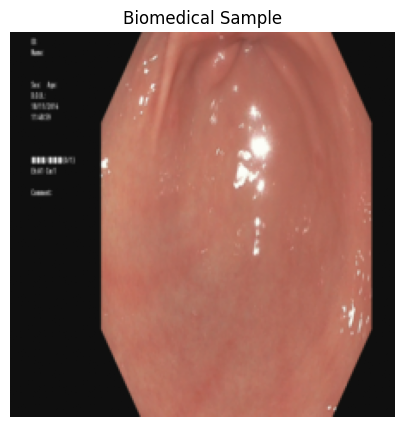

In [18]:
plt.figure(figsize=(5,5))

plt.imshow(
    images[0].permute(1,2,0)
)

plt.title("Biomedical Sample")

plt.axis("off")

plt.show()

Now the dataset pipeline is fully working and ready for:

- image encoder
- multimodal model
- contrastive learning
- training loop
- embedding visualization
- retrieval system

#5. Build Image Encoder

The image encoder extracts meaningful biomedical visual features from endoscopy images.

We use:

- pretrained ResNet50
- transfer learning
- projection head for embedding learning
##Image Encoder Code

In [19]:
class ImageEncoder(nn.Module):

    def __init__(
        self,
        embedding_dim=256
    ):

        super().__init__()

        model = models.resnet50(
            weights=models.ResNet50_Weights.DEFAULT
        )

        self.backbone = nn.Sequential(
            *list(model.children())[:-1]
        )

        self.projection = nn.Linear(
            2048,
            embedding_dim
        )

    def forward(self, x):

        x = self.backbone(x)

        x = x.view(
            x.size(0),
            -1
        )

        x = self.projection(x)

        return x

#6. Build Omics Encoder

The omics encoder transforms:

- synthetic biological vectors

into:

- compact embeddings

This simulates molecular representation learning.

##Omics Encoder Code

In [20]:
class OmicsEncoder(nn.Module):

    def __init__(
        self,
        input_dim=20000,
        embedding_dim=256
    ):

        super().__init__()

        self.encoder = nn.Sequential(

            nn.Linear(
                input_dim,
                4096
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                4096,
                1024
            ),

            nn.ReLU(),

            nn.Linear(
                1024,
                embedding_dim
            )
        )

    def forward(self, x):

        return self.encoder(x)

#7. Build Multimodal Model

This combines:

- image encoder
- omics encoder

into a shared biological representation space.

##Multimodal Model Code

In [21]:
class BioBridge(nn.Module):

    def __init__(
        self,
        image_encoder,
        omics_encoder
    ):

        super().__init__()

        self.image_encoder = image_encoder

        self.omics_encoder = omics_encoder

    def forward(
        self,
        image,
        omics
    ):

        image_embedding = self.image_encoder(
            image
        )

        omics_embedding = self.omics_encoder(
            omics
        )

        return (
            image_embedding,
            omics_embedding
        )

#8. Contrastive Loss

Contrastive learning aligns:

- matching image-omics pairs

and separates:

- non-matching pairs

This is inspired by:

- CLIP
- multimodal foundation models
- self-supervised learning
##Contrastive Loss Code

In [22]:
class ContrastiveLoss(nn.Module):

    def __init__(
        self,
        temperature=0.07
    ):

        super().__init__()

        self.temperature = temperature

    def forward(
        self,
        image_embeddings,
        omics_embeddings
    ):

        image_embeddings = F.normalize(
            image_embeddings,
            dim=1
        )

        omics_embeddings = F.normalize(
            omics_embeddings,
            dim=1
        )

        logits = (
            image_embeddings
            @ omics_embeddings.T
        )

        logits = (
            logits
            / self.temperature
        )

        labels = torch.arange(
            logits.shape[0]
        ).to(logits.device)

        loss_i = F.cross_entropy(
            logits,
            labels
        )

        loss_o = F.cross_entropy(
            logits.T,
            labels
        )

        return (
            loss_i + loss_o
        ) / 2

#9. Training Loop

Now we:

- initialize model
- define optimizer
- train embeddings
- minimize contrastive loss
##Device Setup

In [23]:
DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(DEVICE)

cuda


In [24]:
image_encoder = ImageEncoder()

omics_encoder = OmicsEncoder()

model = BioBridge(
    image_encoder,
    omics_encoder
).to(DEVICE)

criterion = ContrastiveLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 138MB/s]


#Training Code

In [25]:
EPOCHS = 2

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for step, (images, omics) in enumerate(loader):

        images = images.to(DEVICE)

        omics = omics.to(DEVICE)

        image_embeddings, omics_embeddings = model(
            images,
            omics
        )

        loss = criterion(
            image_embeddings,
            omics_embeddings
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        if step % 10 == 0:

            print(
                f"Epoch {epoch} "
                f"Step {step} "
                f"Loss {loss.item():.4f}"
            )

        if step == 100:
            break

    print(
        f"Epoch {epoch} "
        f"Average Loss "
        f"{total_loss / 100:.4f}"
    )

Epoch 0 Step 0 Loss 2.6676
Epoch 0 Step 10 Loss 2.1682
Epoch 0 Step 20 Loss 2.1341
Epoch 0 Step 30 Loss 2.3627
Epoch 0 Step 40 Loss 2.3963
Epoch 0 Step 50 Loss 2.2092
Epoch 0 Step 60 Loss 2.0150
Epoch 0 Step 70 Loss 2.1184
Epoch 0 Step 80 Loss 2.2196
Epoch 0 Step 90 Loss 2.1642
Epoch 0 Step 100 Loss 2.0605
Epoch 0 Average Loss 2.2137
Epoch 1 Step 0 Loss 2.1969
Epoch 1 Step 10 Loss 2.0362
Epoch 1 Step 20 Loss 2.1010
Epoch 1 Step 30 Loss 2.0392
Epoch 1 Step 40 Loss 2.1742
Epoch 1 Step 50 Loss 2.1039
Epoch 1 Step 60 Loss 1.9984
Epoch 1 Step 70 Loss 2.0550
Epoch 1 Step 80 Loss 2.1335
Epoch 1 Step 90 Loss 2.2083
Epoch 1 Step 100 Loss 2.2412
Epoch 1 Average Loss 2.1395


10. Embedding Visualization

Now we visualize the learned biomedical embedding space.

This demonstrates:

- representation learning
- biological clustering
- multimodal structure learning
##Generate Embeddings

In [26]:
all_embeddings = []

model.eval()

with torch.no_grad():

    for step, (images, omics) in enumerate(loader):

        images = images.to(DEVICE)

        embeddings = model.image_encoder(
            images
        )

        all_embeddings.append(
            embeddings.cpu().numpy()
        )

        if step == 20:
            break

#Apply UMAP

In [27]:
embeddings = np.concatenate(
    all_embeddings
)

reducer = umap.UMAP()

reduced = reducer.fit_transform(
    embeddings
)

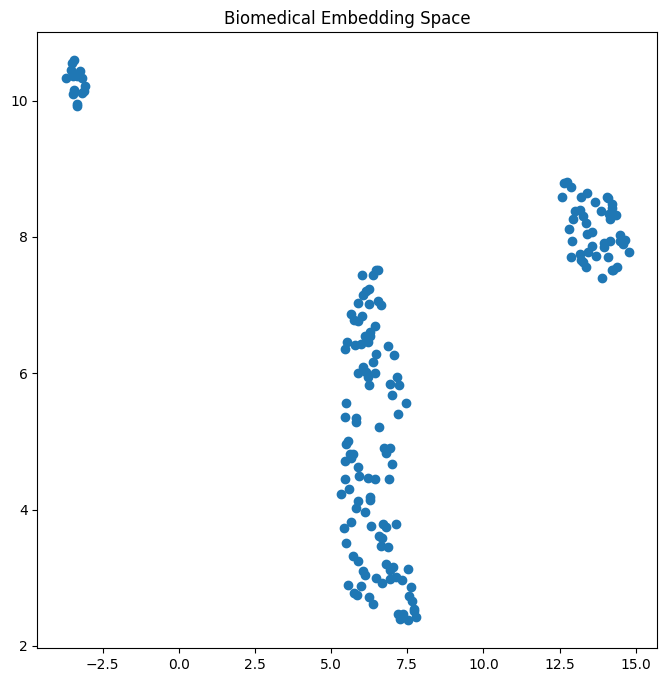

In [28]:
plt.figure(figsize=(8,8))

plt.scatter(
    reduced[:,0],
    reduced[:,1]
)

plt.title(
    "Biomedical Embedding Space"
)

plt.show()

#11. Cross-modal Retrieval

Cross-modal retrieval finds:

- similar biological embeddings
- nearest biomedical representations

This mimics:

- biological similarity search
- multimodal retrieval systems
##Retrieval Function

In [29]:
def retrieve_similar(
    query_embedding,
    gallery_embeddings,
    top_k=5
):

    similarities = torch.matmul(
        query_embedding,
        gallery_embeddings.T
    )

    indices = similarities.topk(
        top_k
    ).indices

    return indices

In [30]:
query = embeddings[0]

gallery = torch.tensor(
    embeddings
)

query = torch.tensor(query)

indices = retrieve_similar(
    query,
    gallery
)

print(indices)

tensor([113,  70, 139, 137,  25])


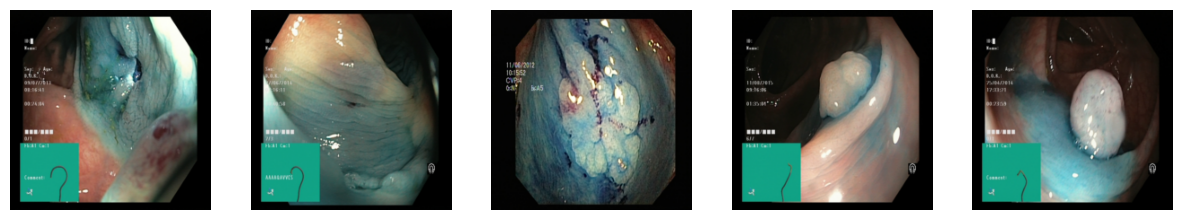

In [31]:
fig, axes = plt.subplots(
    1,
    5,
    figsize=(15,5)
)

for i, idx in enumerate(indices):

    image, _ = dataset[idx]

    axes[i].imshow(
        image.permute(1,2,0)
    )

    axes[i].axis("off")

plt.show()

In [32]:
torch.save(
    model.state_dict(),
    "biobridge.pt"
)

#13. Inference Demo

This demonstrates inference on unseen biomedical images.

##Load Model

In [33]:
model.load_state_dict(
    torch.load("biobridge.pt")
)

model.eval()

BioBridge(
  (image_encoder): ImageEncoder(
    (backbone): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=Tr

#Generate Embeddings for New Samples

In [34]:
sample_image, sample_omics = next(
    iter(loader)
)

sample_image = sample_image.to(DEVICE)

with torch.no_grad():

    embedding = model.image_encoder(
        sample_image
    )

print(
    embedding.shape
)

torch.Size([8, 256])
